# Pipeline SVM para Predicción de Diabetes - Grupo 1
## Ingesta, Limpieza y Preparación de Datos
#### Daniel Huarita - David Moya - Iñaki Asúa - Juan María Jiménez

## 0. Introducción

Este notebook implementa un pipeline de ingesta de datos coherente con el Análisis Exploratorio de Datos (AED) realizado en Grupo1_AED.ipynb.

### Características principales:
- **Ingesta de datos**: Carga desde CSV con validaciones
- **Limpieza**: Aplica criterios del AED (BMI >= 65, gender == 'Other', redondeo de edad)
- **Procesamiento de smoking_history**: Merge de 6 categorías originales a 4 categorías finales:
  - `NoInfo`: "No Info"
  - `NeverSmoked`: "never"
  - `HasSmoked`: "ever", "not current", "former" (fumadores históricos)
  - `Smoking`: "current" (fumadores activos)
- **Preparación para SVM**: Escalado de numéricas, one-hot encoding de categóricas
- **Split train/test**: Estratificado según target (diabetes)

## 1. Importaciones y Setup

In [2]:
# Importamos librerías estándar
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# Aseguramos que el root del repositorio esté en el path de importación
repo_root = Path.cwd().resolve().parent
sys.path.insert(0, str(repo_root))

# Importamos el pipeline modularizado desde SVM_model
from SVM_model.pipeline import (
    load_data,
    clean_data,
    merge_smoking,
    preprocess,
    build_preprocessor,
    build_svm_pipeline,
    get_train_test,
    SMOKING_MAP,
    CAT_FEATURES,
    NUM_FEATURES,
    BINARY_FEATURES,
    ALL_FEATURES,
    TARGET
 )

print("✓ Importaciones completadas correctamente")

✓ Importaciones completadas correctamente


c:\Users\juaji\AFI\trabajo_grupal_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Paso 1: Carga de Datos

Cargamos el dataset desde el archivo CSV. Este dataset contiene:
- **100,000 observaciones** de pacientes
- **9 columnas**: 8 características predictoras + 1 variable objetivo (diabetes)

In [3]:
from pathlib import Path
import os

cwd = Path.cwd().resolve()
repo_root = cwd.parent
os.chdir(repo_root)

# Movemos el lugar de ejecución al root del repo
print(f"Directorio actual: {Path.cwd()}")
print(f"Root del repo: {repo_root}")

Directorio actual: C:\Users\juaji\AFI\trabajo_grupal_2
Root del repo: C:\Users\juaji\AFI\trabajo_grupal_2


In [4]:
# Paso 1: Cargamos los datos
df = load_data()

print(f"Dataset cargado:")
print(f"  - Shape: {df.shape}")
print(f"  - Columnas: {list(df.columns)}")
print(f"\nInfo del dataset:")
print(df.info())
print(f"\nPrimeras 5 filas:")
df.head()

Dataset cargado:
  - Shape: (100000, 9)
  - Columnas: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None

Primeras 5 filas:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Paso 2: Análisis de Smoking History (Antes del Merge)

Antes de hacer el merge, examinemos las categorías originales de `smoking_history`:

In [5]:
# Examinamos la variable smoking_history antes del procesamiento
print("Categorías originales de smoking_history:")
smoking_counts = df['smoking_history'].value_counts()
print(smoking_counts)
print(f"\nTotal: {smoking_counts.sum()}")

# Prevalencia de diabetes por categoría original
print("\nDiabetes prevalence por smoking_history (original):")
diabetes_by_smoking = df.groupby('smoking_history')['diabetes'].agg(['count', 'sum', 'mean'])
diabetes_by_smoking.columns = ['Total', 'Con_Diabetes', 'Prevalencia_%']
diabetes_by_smoking['Prevalencia_%'] = (diabetes_by_smoking['Prevalencia_%'] * 100).round(2)
print(diabetes_by_smoking)

Categorías originales de smoking_history:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

Total: 100000

Diabetes prevalence por smoking_history (original):
                 Total  Con_Diabetes  Prevalencia_%
smoking_history                                    
No Info          35816          1454           4.06
current           9286           948          10.21
ever              4004           472          11.79
former            9352          1590          17.00
never            35095          3346           9.53
not current       6447           690          10.70


## 4. Paso 3: Mapeo de Smoking History

Fusionamos las 6 categorías originales en 4 categorías coherentes:

| Original | Fusionado | Descripción |
|----------|-----------|-------------|
| No Info | NoInfo | Información no disponible |
| never | NeverSmoked | Nunca han fumado |
| ever, not current, former | HasSmoked | Han fumado pero no actualmente |
| current | Smoking | Fumadores activos |

El mapeo se define en `SMOKING_MAP`:

In [6]:
# Mostramos el mapeo que usaremos
print("Mapeo de smoking_history:")
for original, nuevo in SMOKING_MAP.items():
    print(f"  {original:15s} → {nuevo}")

Mapeo de smoking_history:
  No Info         → NoInfo
  never           → NeverSmoked
  ever            → HasSmoked
  not current     → HasSmoked
  former          → HasSmoked
  current         → Smoking


In [7]:
# Paso 3: Aplicamos el merge de smoking_history
df_merged = merge_smoking(df.copy())

print("Categorías después del merge:")
smoking_merged_counts = df_merged['smoking_history'].value_counts()
print(smoking_merged_counts)
print(f"\nTotal: {smoking_merged_counts.sum()}")

# Prevalencia de diabetes por categoría fusionada
print("\nDiabetes prevalence por smoking_history (fusionado):")
diabetes_by_smoking_merged = df_merged.groupby('smoking_history')['diabetes'].agg(['count', 'sum', 'mean'])
diabetes_by_smoking_merged.columns = ['Total', 'Con_Diabetes', 'Prevalencia_%']
diabetes_by_smoking_merged['Prevalencia_%'] = (diabetes_by_smoking_merged['Prevalencia_%'] * 100).round(2)
print(diabetes_by_smoking_merged)

Categorías después del merge:
smoking_history
NoInfo         35816
NeverSmoked    35095
HasSmoked      19803
Smoking         9286
Name: count, dtype: int64

Total: 100000

Diabetes prevalence por smoking_history (fusionado):
                 Total  Con_Diabetes  Prevalencia_%
smoking_history                                    
HasSmoked        19803          2752          13.90
NeverSmoked      35095          3346           9.53
NoInfo           35816          1454           4.06
Smoking           9286           948          10.21


## 5. Paso 4: Limpieza de Datos

Aplicamos los criterios de limpieza del AED (Grupo1_AED.ipynb):
1. **Eliminar BMI >= 65**: 47 observaciones (outliers extremos)
2. **Eliminar gender == 'Other'**: ~18 observaciones
3. **Redondear age**: Valores no-enteros solo en niños < 2 años

Justificación en AED: estos cambios mejoran la estabilidad del modelo sin perder información relevante.

In [8]:
# Paso 4: Limpieza de datos (aplicamos clean_data)
print("Estado antes de limpieza:")
print(f"  - Shape: {df.shape}")
print(f"  - BMI max: {df['bmi'].max()}")
print(f"  - Gender unique: {df['gender'].unique()}")
print(f"  - Age type: {df['age'].dtype}")

df_clean = clean_data(df.copy())

print("\nEstado después de limpieza:")
print(f"  - Shape: {df_clean.shape}")
print(f"  - BMI max: {df_clean['bmi'].max()}")
print(f"  - Gender unique: {df_clean['gender'].unique()}")
print(f"  - Age type: {df_clean['age'].dtype}")

print(f"\nFilas eliminadas: {df.shape[0] - df_clean.shape[0]} ({((df.shape[0] - df_clean.shape[0])/df.shape[0]*100):.2f}%)")

Estado antes de limpieza:
  - Shape: (100000, 9)
  - BMI max: 95.69
  - Gender unique: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
  - Age type: float64

Estado después de limpieza:
  - Shape: (99935, 9)
  - BMI max: 64.8
  - Gender unique: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
  - Age type: int64

Filas eliminadas: 65 (0.07%)


## 6. Paso 5: Pipeline Completo de Preprocesamiento

Combinamos todos los pasos anteriores en un único flujo `preprocess()`:
1. Limpieza
2. Merge de smoking_history
3. Separación en X (características) e y (target)

In [9]:
# Paso 5: Pipeline completo de preprocesamiento
X, y = preprocess(df)

print(f"Dataset después de preprocess:")
print(f"  - X shape: {X.shape}")
print(f"  - y shape: {y.shape}")
print(f"  - X features: {list(X.columns)}")

print(f"\nDistribución del target (diabetes):")
print(y.value_counts())
print(f"\nPrevalencia de diabetes: {(y.sum()/len(y)*100):.2f}%")

print(f"\nCategorías finales de smoking_history:")
print(X['smoking_history'].value_counts())

Dataset después de preprocess:
  - X shape: (99935, 8)
  - y shape: (99935,)
  - X features: ['gender', 'smoking_history', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']

Distribución del target (diabetes):
diabetes
0    91450
1     8485
Name: count, dtype: int64

Prevalencia de diabetes: 8.49%

Categorías finales de smoking_history:
smoking_history
NoInfo         35800
NeverSmoked    35071
HasSmoked      19786
Smoking         9278
Name: count, dtype: int64


## 7. Paso 6: Estadísticas Descriptivas de X

Revisemos las características que van a alimentar el modelo SVM:

In [10]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de X:")
print(X.describe())

print("\nTipos de datos:")
print(X.dtypes)

print("\nValores faltantes:")
print(X.isnull().sum())

print(f"\nVariables categóricas: {CAT_FEATURES}")
print(f"Variables numéricas: {NUM_FEATURES}")
print(f"Variables binarias: {BINARY_FEATURES}")

Estadísticas descriptivas de X:
                age           bmi   HbA1c_level  blood_glucose_level  \
count  99935.000000  99935.000000  99935.000000         99935.000000   
mean      41.887607     27.299311      5.527287           138.049632   
std       22.520111      6.561621      1.070625            40.697672   
min        0.000000     10.010000      3.500000            80.000000   
25%       24.000000     23.630000      4.800000           100.000000   
50%       43.000000     27.320000      5.800000           140.000000   
75%       60.000000     29.570000      6.200000           159.000000   
max       80.000000     64.800000      9.000000           300.000000   

       hypertension  heart_disease  
count  99935.000000   99935.000000  
mean       0.074819       0.039416  
std        0.263100       0.194583  
min        0.000000       0.000000  
25%        0.000000       0.000000  
50%        0.000000       0.000000  
75%        0.000000       0.000000  
max        1.000000    

## 8. Paso 7: Split Train/Test

Dividimos los datos en conjuntos de entrenamiento y prueba:
- **Test size**: 20% (default 0.2)
- **Estratificación**: Mantenemos la proporción de diabetes en ambos sets
- **Random state**: 42 (reproducibilidad)

In [11]:
# Paso 7: Split train/test
X_train, X_test, y_train, y_test = get_train_test(X, y)

print(f"Split Train/Test:")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - X_test shape:  {X_test.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - y_test shape:  {y_test.shape}")

print(f"\nProporción de diabetes en train: {(y_train.sum()/len(y_train)*100):.2f}%")
print(f"Proporción de diabetes en test:  {(y_test.sum()/len(y_test)*100):.2f}%")

print(f"\nDistribución y_train:")
print(y_train.value_counts())

print(f"\nDistribución y_test:")
print(y_test.value_counts())

Split Train/Test:
  - X_train shape: (79948, 8)
  - X_test shape:  (19987, 8)
  - y_train shape: (79948,)
  - y_test shape:  (19987,)

Proporción de diabetes en train: 8.49%
Proporción de diabetes en test:  8.49%

Distribución y_train:
diabetes
0    73160
1     6788
Name: count, dtype: int64

Distribución y_test:
diabetes
0    18290
1     1697
Name: count, dtype: int64


## 9. Paso 8: Construcción del Preprocesador (ColumnTransformer)

Construimos un `ColumnTransformer` que aplica transformaciones específicas a cada tipo de variable:
- **Numéricas** (`age`, `bmi`, `HbA1c_level`, `blood_glucose_level`): `StandardScaler` (media=0, std=1)
- **Categóricas** (`gender`, `smoking_history`): `OneHotEncoder` (drop='first')
- **Binarias** (`hypertension`, `heart_disease`): passthrough (sin transformación)

In [12]:
# Paso 8: Construimos el preprocesador
preprocessor = build_preprocessor()

print("Preprocesador construido:")
print(f"  - Transformaciones:")
print(f"    1. Numéricas ({NUM_FEATURES}): StandardScaler")
print(f"    2. Categóricas ({CAT_FEATURES}): OneHotEncoder (drop='first')")
print(f"    3. Binarias ({BINARY_FEATURES}): passthrough")

# Ajustamos el preprocesador (fit) con los datos de train
preprocessor.fit(X_train)

# Transformamos train y test
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nDatos transformados:")
print(f"  - X_train_transformed shape: {X_train_transformed.shape}")
print(f"  - X_test_transformed shape:  {X_test_transformed.shape}")
print(f"\nNota: Se crearon más features por el one-hot encoding:")
print(f"  - Original: {X_train.shape[1]} features")
print(f"  - Después: {X_train_transformed.shape[1]} features")

Preprocesador construido:
  - Transformaciones:
    1. Numéricas (['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']): StandardScaler
    2. Categóricas (['gender', 'smoking_history']): OneHotEncoder (drop='first')
    3. Binarias (['hypertension', 'heart_disease']): passthrough

Datos transformados:
  - X_train_transformed shape: (79948, 10)
  - X_test_transformed shape:  (19987, 10)

Nota: Se crearon más features por el one-hot encoding:
  - Original: 8 features
  - Después: 10 features


## 10. Paso 9: Construcción del Pipeline SVM

Construimos un `sklearn.Pipeline` que encadena:
1. **Preprocesador** (ColumnTransformer) - escalado y encoding
2. **SVM** (Support Vector Machine) - clasificador

Parámetros del SVM:
- `kernel='rbf'`: Radial Basis Function (no lineal)
- `C=1.0`: Parámetro de regularización
- `gamma='scale'`: Parámetro del kernel RBF
- `class_weight='balanced'`: Compensa desbalance de clases
- `probability=True`: Permite predict_proba()

In [13]:
# Paso 9: Construimos el pipeline SVM
svm_pipeline = build_svm_pipeline(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced'
)

print("Pipeline SVM construido:")
print(svm_pipeline)

print(f"\nComponentes del pipeline:")
for name, step in svm_pipeline.named_steps.items():
    print(f"  - {name}: {step.__class__.__name__}")

Pipeline SVM construido:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease'])])),
                ('svm',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

Componentes del

## 11. Paso 10: Entrenamiento del Pipeline SVM

Entrenamos el modelo SVM con los datos de entrenamiento.

**Nota**: Este paso puede tomar tiempo en la primera ejecución debido al tamaño del dataset (~80k muestras).

In [14]:
# Paso 10: Entrenamos el pipeline
import time

print("Entrenando pipeline SVM...")
t0 = time.time()

svm_pipeline.fit(X_train, y_train)

elapsed = time.time() - t0
print(f"✓ Entrenamiento completado en {elapsed:.2f} segundos")

Entrenando pipeline SVM...
✓ Entrenamiento completado en 942.48 segundos


## 12. Paso 11: Evaluación del Modelo

Evaluamos el rendimiento del modelo en el conjunto de test usando múltiples métricas:

In [15]:
# Paso 11: Evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Cálculo de métricas train
y_pred_train = svm_pipeline.predict(X_train)
y_pred_proba_train = svm_pipeline.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)
train_roc_auc = roc_auc_score(y_train, y_pred_proba_train)

print("Métricas de rendimiento en Train Set:")
print(f"  - Accuracy:  {train_accuracy:.4f}")
print(f"  - Precision: {train_precision:.4f}")
print(f"  - Recall:    {train_recall:.4f}")
print(f"  - F1-Score:  {train_f1:.4f}")
print(f"  - ROC-AUC:   {train_roc_auc:.4f}")

print(f"\nMatriz de confusión:")
cm = confusion_matrix(y_train, y_pred_train)
print(cm)


# Cálculo de métricas test
y_pred = svm_pipeline.predict(X_test)
y_pred_proba = svm_pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Métricas de rendimiento en Test Set:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - ROC-AUC:   {roc_auc:.4f}")

print(f"\nMatriz de confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(f"\nReporte de clasificación test:")
print(classification_report(y_test, y_pred, target_names=['Sin Diabetes', 'Con Diabetes']))

Métricas de rendimiento en Train Set:
  - Accuracy:  0.8931
  - Precision: 0.4384
  - Recall:    0.9204
  - F1-Score:  0.5939
  - ROC-AUC:   0.9734

Matriz de confusión:
[[65157  8003]
 [  540  6248]]
Métricas de rendimiento en Test Set:
  - Accuracy:  0.8949
  - Precision: 0.4433
  - Recall:    0.9287
  - F1-Score:  0.6002
  - ROC-AUC:   0.9736

Matriz de confusión:
[[16311  1979]
 [  121  1576]]

Reporte de clasificación test:
              precision    recall  f1-score   support

Sin Diabetes       0.99      0.89      0.94     18290
Con Diabetes       0.44      0.93      0.60      1697

    accuracy                           0.89     19987
   macro avg       0.72      0.91      0.77     19987
weighted avg       0.95      0.89      0.91     19987



## 12A. Optimización de Threshold

Ajustamos el umbral de decisión para maximizar F1, comparando respecto al modelo baseline (umbral 0.5).

Threshold óptimo (max F2): 0.23
  Precision: 0.5654
  Recall:    0.8503
  F1:        0.6792
  F2:        0.7725

Comparación Baseline vs Threshold Óptimo:
Métrica      Baseline (0.5)   Óptimo       Cambio    
--------------------------------------------------
Precision    0.4433           0.5654       +0.1221   
Recall       0.9287           0.8503       -0.0784   
F1           0.6002           0.6792       +0.0791   


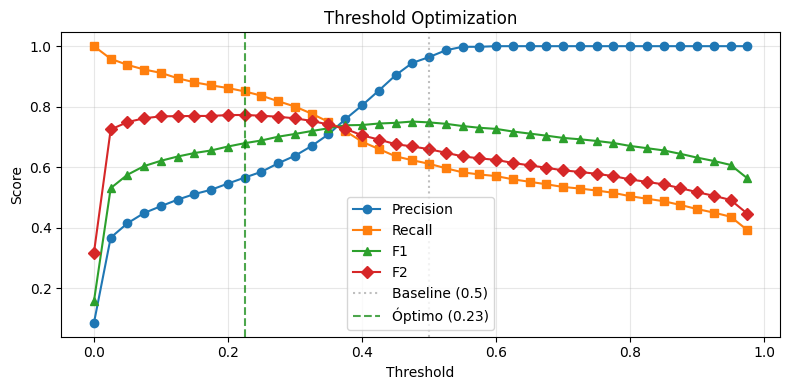


Matriz de confusión con threshold óptimo (0.23):
[[17181  1109]
 [  254  1443]]


In [25]:
# Threshold optimization
import json
from sklearn.metrics import fbeta_score
thresholds = np.arange(0.0, 1.0, 0.025)
scores = []
for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    scores.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t),
        'f2': fbeta_score(y_test, y_pred_t, beta=2)
    })
df_t = pd.DataFrame(scores)
best_t = df_t.loc[df_t['f2'].idxmax()]
print(f'Threshold óptimo (max F2): {best_t["threshold"]:.2f}')
print(f'  Precision: {best_t["precision"]:.4f}')
print(f'  Recall:    {best_t["recall"]:.4f}')
print(f'  F1:        {best_t["f1"]:.4f}')
print(f'  F2:        {best_t["f2"]:.4f}')

# Comparison with baseline (threshold=0.5)
print(f'\nComparación Baseline vs Threshold Óptimo:')
print(f'{"Métrica":<12} {"Baseline (0.5)":<16} {"Óptimo":<12} {"Cambio":<10}')
print('-' * 50)
print(f'{"Precision":<12} {precision:<16.4f} {best_t["precision"]:<12.4f} {best_t["precision"]-precision:<+10.4f}')
print(f'{"Recall":<12} {recall:<16.4f} {best_t["recall"]:<12.4f} {best_t["recall"]-recall:<+10.4f}')
print(f'{"F1":<12} {f1:<16.4f} {best_t["f1"]:<12.4f} {best_t["f1"]-f1:<+10.4f}')
# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_t['threshold'], df_t['precision'], label='Precision', marker='o')
ax.plot(df_t['threshold'], df_t['recall'], label='Recall', marker='s')
ax.plot(df_t['threshold'], df_t['f1'], label='F1', marker='^')
ax.plot(df_t['threshold'], df_t['f2'], label='F2', marker='D')
ax.axvline(x=0.5, color='gray', ls=':', alpha=0.5, label='Baseline (0.5)')
ax.axvline(x=best_t['threshold'], color='green', ls='--', alpha=0.7, label=f'Óptimo ({best_t["threshold"]:.2f})')
ax.set(xlabel='Threshold', ylabel='Score', title='Threshold Optimization')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cm_opt = confusion_matrix(y_test, (y_pred_proba >= best_t['threshold']).astype(int))
print(f'\nMatriz de confusión con threshold óptimo ({best_t["threshold"]:.2f}):')
print(cm_opt)

# Guardar métricas del modelo con threshold optimizado en artifacts/metrics_baseline_optimized_cv.json
opt_metrics = {
    'Precision': best_t['precision'], 
    'Recall': best_t['recall'], 
    'F1': best_t['f1'],
    'PR-AUC': None,  # Placeholder, calcular si es necesario
    'ROC-AUC': roc_auc,  # No cambia con el threshold,
    'threshold': best_t['threshold'],
    'cm': cm_opt.tolist()  # Guardamos la matriz de confusión como lista para JSON
}

with open('SVM_model/artifacts/metrics_baseline_optimized.json', 'w') as f:
    json.dump(opt_metrics, f, indent=2)

Features: 10
Entrenando SVM pequeno para SHAP (10000 muestras)...
SVM pequeno listo en 3s
SV: 1013
SHAP values...


100%|██████████| 50/50 [00:37<00:00,  1.32it/s]

SHAP listo en 38s


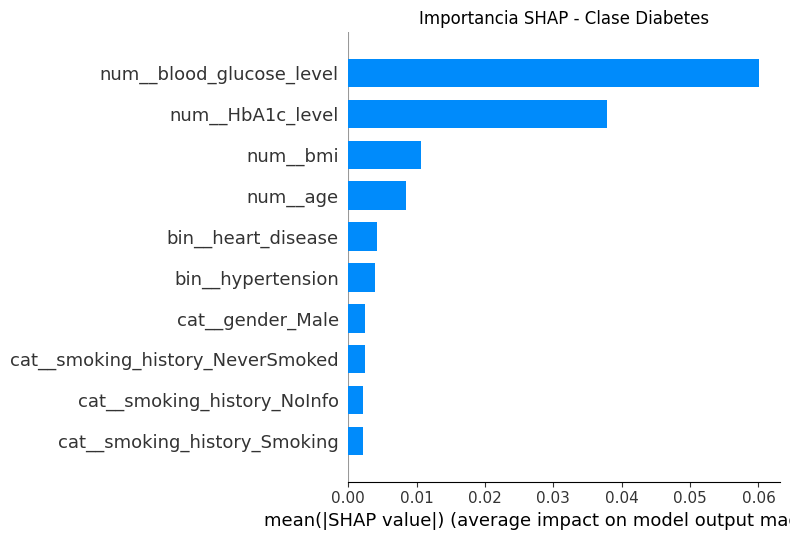

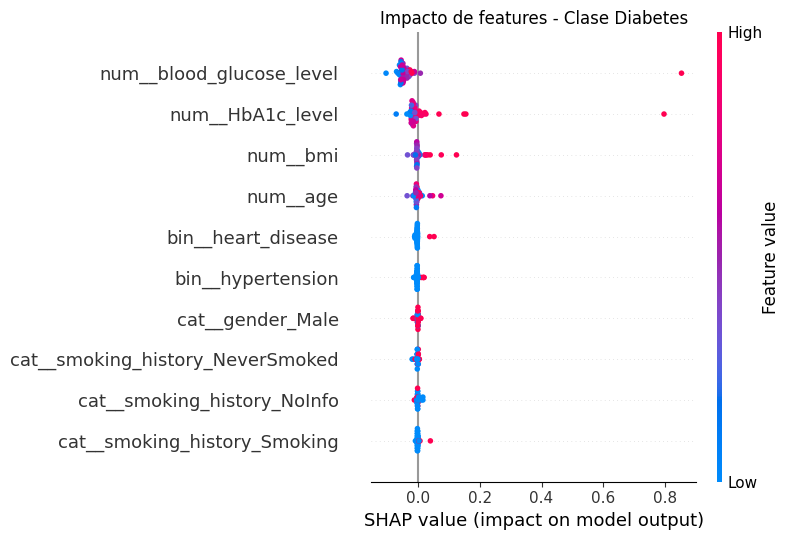

In [20]:
# SHAP con SVM pequeno (KernelExplainer en modelo grande es inviable)
# Entrenamos un SVM ligero en 2000 muestras solo para SHAP
Xp_train = svm_pipeline.named_steps['preprocessor'].transform(X_train)
Xp_test = svm_pipeline.named_steps['preprocessor'].transform(X_test)
fnames = list(svm_pipeline.named_steps['preprocessor'].get_feature_names_out())
print(f'Features: {len(fnames)}')

rng = np.random.default_rng(42)
idx = rng.choice(Xp_train.shape[0], 10000, replace=False)
X_sub = Xp_train[idx]
y_sub = y_train.values[idx] if hasattr(y_train, 'values') else y_train[idx]
print(f'Entrenando SVM pequeno para SHAP ({X_sub.shape[0]} muestras)...')
from sklearn.svm import SVC as SVC_shap
svm_shap = SVC_shap(kernel='rbf', probability=True, random_state=42)
t0 = time.time()
svm_shap.fit(X_sub, y_sub)
print(f'SVM pequeno listo en {time.time()-t0:.0f}s')
print(f'SV: {sum(svm_shap.n_support_)}')

bg = Xp_train[rng.choice(Xp_train.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(svm_shap.predict_proba, bg)
X_shap = Xp_test[rng.choice(Xp_test.shape[0], 50, replace=False)]
print('SHAP values...')
t0 = time.time()
sv = explainer.shap_values(X_shap, nsamples=100)
print(f'SHAP listo en {time.time()-t0:.0f}s')
n = X_shap.shape[0]
if len(sv) == 2 and sv[0].shape[0] == n:
    shap_class1 = sv[1]
else:
    shap_class1 = np.array([sv_i[:, 1] for sv_i in sv])

if shap_class1.shape[1] == X_shap.shape[1]:
    feat = fnames[:shap_class1.shape[1]]
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, plot_type='bar', show=False)
    plt.title('Importancia SHAP - Clase Diabetes')
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, show=False)
    plt.title('Impacto de features - Clase Diabetes')
    plt.tight_layout(); plt.show()
else:
    print(f'Shape mismatch: shap_class1={shap_class1.shape} vs X_shap={X_shap.shape}')


## 13. Exportación de Artifacts

Podemos guardar el modelo entrenado para usar después:

In [21]:
# Exportamos el modelo entrenado (opcional)
import joblib
import os

# Crear carpeta de artifacts si no existe
os.makedirs('SVM_model/artifacts', exist_ok=True)

# Guardar modelo
model_path = 'SVM_model/artifacts/svm_model_trained.pkl'
joblib.dump(svm_pipeline, model_path)
print(f"✓ Modelo guardado en: {model_path}")

# Guardar preprocessor por separado
preprocessor_path = 'SVM_model/artifacts/preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_path)
print(f"✓ Preprocesador guardado en: {preprocessor_path}")

# Guardar métricas
import json
metrics = {
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'test_size': len(X_test),
    'train_size': len(X_train)
}
metrics_path = 'SVM_model/artifacts/metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Métricas guardadas en: {metrics_path}")

✓ Modelo guardado en: SVM_model/artifacts/svm_model_trained.pkl
✓ Preprocesador guardado en: SVM_model/artifacts/preprocessor.pkl
✓ Métricas guardadas en: SVM_model/artifacts/metrics.json
